In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
uploaded = files.upload()


Saving c83e6fd1-4cd6-4369-8a52-01eaf8593759.png to c83e6fd1-4cd6-4369-8a52-01eaf8593759.png


In [3]:
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)

print("Image loaded successfully!")
print("Filename:", filename)
print("Image shape:", image.shape)

Image loaded successfully!
Filename: c83e6fd1-4cd6-4369-8a52-01eaf8593759.png
Image shape: (1254, 1254, 3)


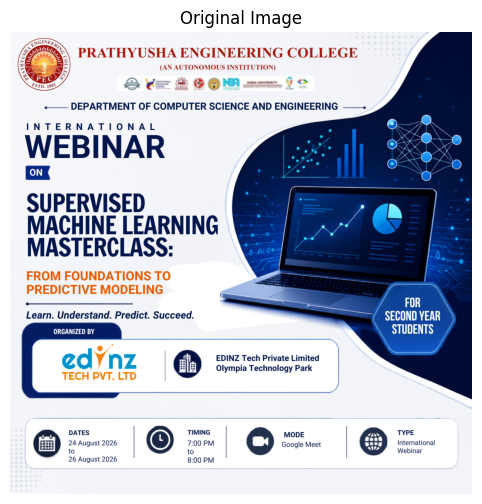

In [4]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()

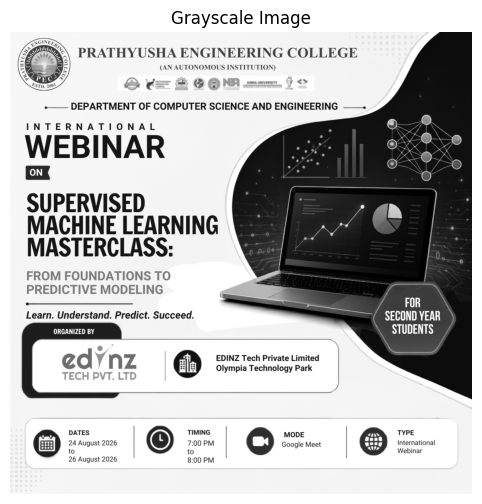

In [5]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.title("Grayscale Image")
plt.show()

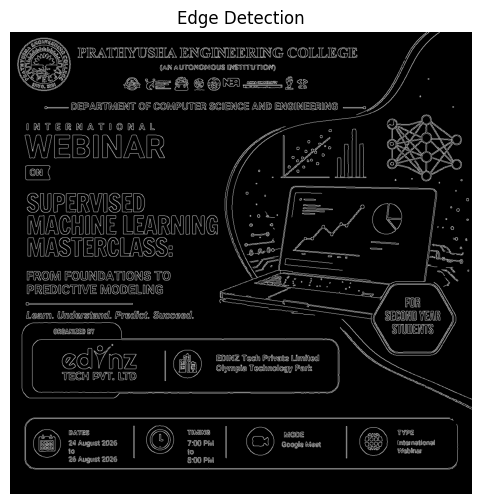

In [6]:
edges = cv2.Canny(gray_image, 100, 200)

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.title("Edge Detection")
plt.show()

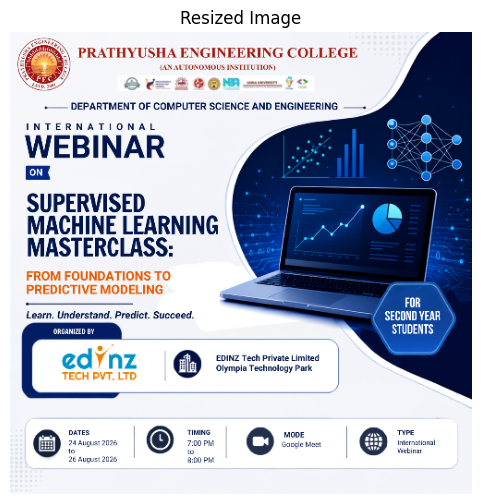

In [7]:
resized_image = cv2.resize(image, (500, 500))

resized_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(resized_rgb)
plt.axis("off")
plt.title("Resized Image")
plt.show()

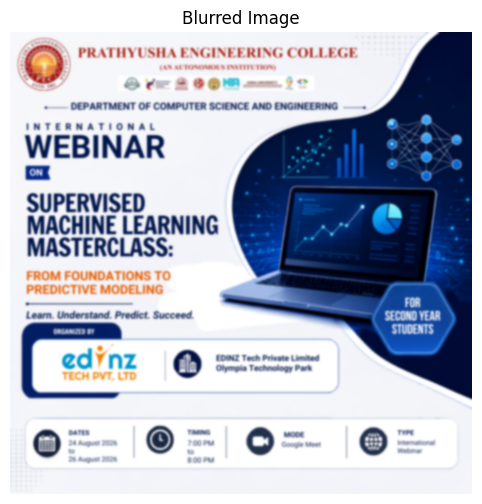

In [8]:
blurred_image = cv2.GaussianBlur(image, (15, 15), 0)

blurred_rgb = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(blurred_rgb)
plt.axis("off")
plt.title("Blurred Image")
plt.show()

In [9]:
output_filename = "processed_grayscale.jpg"

cv2.imwrite(output_filename, gray_image)

print("Processed image saved successfully!")

Processed image saved successfully!


In [10]:
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os

project_folder = "/content/drive/MyDrive/Cloud_Image_Processing"

input_folder = os.path.join(project_folder, "Input")
output_folder = os.path.join(project_folder, "Output")

os.makedirs(input_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

print("Cloud storage folders created!")

Cloud storage folders created!


In [13]:
drive_output = os.path.join(output_folder, "grayscale_output.jpg")

cv2.imwrite(drive_output, gray_image)

print("Image saved to Google Drive!")
print(drive_output)

Image saved to Google Drive!
/content/drive/MyDrive/Cloud_Image_Processing/Output/grayscale_output.jpg


In [14]:
!pip install -q gradio

In [15]:
import gradio as gr
import os
import time
import cv2
import numpy as np

In [16]:
def cloud_process(image, operation):
    if image is None:
        return None, "Please upload an image.", "", ""

    # Gradio gives us an RGB image
    rgb_image = np.array(image)

    # Convert RGB → BGR for OpenCV
    bgr_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)

    start_time = time.perf_counter()

    # Process image
    processed = process_image(bgr_image, operation)

    processing_time = time.perf_counter() - start_time

    # Convert processed image back to RGB for display
    if len(processed.shape) == 2:
        display_image = processed
    else:
        display_image = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    # Create output filename
    output_filename = f"processed_{operation.lower().replace(' ', '_')}.jpg"
    output_path = os.path.join(OUTPUT_DIR, output_filename)

    # Save to Google Drive
    if len(processed.shape) == 2:
        cv2.imwrite(output_path, processed)
    else:
        cv2.imwrite(output_path, processed)

    input_size = rgb_image.nbytes / 1024
    output_size = os.path.getsize(output_path) / 1024

    status = "✅ Processing completed successfully!"

    details = f"""
### Processing Details

**Operation:** {operation}

**Processing Time:** {processing_time:.4f} seconds

**Input Size:** {input_size:.2f} KB

**Output Size:** {output_size:.2f} KB

**Cloud Runtime:** Google Colab

**Cloud Storage:** Google Drive

**Status:** {status}
"""

    return display_image, details, output_path, status

In [17]:
with gr.Blocks(title="Cloud Image Processor") as app:

    gr.Markdown(
        """
        # ☁️ Cloud Image Processor
        ### Process your images using cloud computing

        Upload an image, select an operation, and process it using
        **Google Colab's cloud runtime**. Processed images are stored
        in **Google Drive**.
        """
    )

    with gr.Row():

        # LEFT SIDE
        with gr.Column():

            input_image = gr.Image(
                type="pil",
                label="📤 Upload Image"
            )

            operation = gr.Dropdown(
                choices=[
                    "Grayscale",
                    "Resize",
                    "Blur",
                    "Edge Detection",
                    "Sharpen",
                    "Brightness Enhancement"
                ],
                value="Grayscale",
                label="⚙️ Processing Operation"
            )

            process_button = gr.Button(
                "🚀 PROCESS IMAGE",
                variant="primary"
            )

        # RIGHT SIDE
        with gr.Column():

            output_image = gr.Image(
                label="🖼️ Processed Image"
            )

            status = gr.Textbox(
                label="System Status"
            )

    gr.Markdown("## 📊 Processing Information")

    details = gr.Markdown(
        "Upload an image and click **PROCESS IMAGE**."
    )

    output_path = gr.Textbox(
        label="☁️ Google Drive Output Path"
    )

    process_button.click(
        fn=cloud_process,
        inputs=[
            input_image,
            operation
        ],
        outputs=[
            output_image,
            details,
            output_path,
            status
        ]
    )

    gr.Markdown(
        """
        ---
        **Cloud Computing:** Google Colab ☁️
        **Cloud Storage:** Google Drive 💾
        **Image Processing:** Python + OpenCV 🐍
        """
    )

In [18]:
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8959b6548336b3825a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
